# Customer Churn Analysis


 ####                       By Kumar Wankhade ( Data Analyst )

In [365]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

plt.rcParams['figure.autolayout']


False

## 1. Import Data

In [366]:

df=pd.read_csv("credit_card_customer_churn_dataset.csv")
df

,customer_id,age,gender,marital_status,education_level,employment_status,income,city,credit_score,account_age_months,...,support_satisfaction,reward_points,offers_received,offers_redeemed,financial_stress_score,engagement_score,customer_value_score,churn_risk_score,churn_probability,churned
0,CUST-0000001,50,Male,Divorced,Bachelor,Employed,31679.55,San Diego,685,151,...,4.1,728,3,1,50.33,74.89,54.35,13.00,0.1300,0
1,CUST-0000002,42,Female,Married,Bachelor,Self-Employed,83618.66,Los Angeles,732,81,...,3.3,13537,3,2,17.70,85.36,99.34,4.30,0.0430,0
2,CUST-0000003,52,Male,Married,Bachelor,Self-Employed,134295.30,Phoenix,777,41,...,3.2,4671,4,2,15.67,74.81,30.56,3.32,0.0332,0
3,CUST-0000004,63,Female,Married,Bachelor,Employed,100983.46,New York,708,54,...,3.1,12694,4,0,13.13,47.55,80.07,19.30,0.1930,0
4,CUST-0000005,40,Male,Married,Bachelor,Employed,89736.89,Other,664,95,...,4.5,37007,1,1,44.25,58.71,100.00,15.10,0.1510,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUST-0099996,41,Male,Widowed,Bachelor,Retired,15000.00,Houston,726,9,...,4.1,1553,2,0,30.57,41.15,38.36,38.13,0.3813,1
99996,CUST-0099997,36,Female,Married,Bachelor,Employed,27693.04,New York,669,45,...,3.8,1646,4,2,35.87,78.59,42.17,9.85,0.0985,0
99997,CUST-0099998,49,Female,Married,High School,Retired,62106.99,San Diego,653,43,...,2.8,4038,3,1,30.89,72.45,42.23,8.93,0.0893,0
99998,CUST-0099999,41,Female,Married,Associate,Employed,97903.38,Other,625,35,...,3.0,4907,3,0,14.24,61.02,46.76,3.72,0.0372,0


## 2. Data Understanding


In [367]:
df.head()
print(df.shape)


(100000, 40)


In [368]:
df.tail()

,customer_id,age,gender,marital_status,education_level,employment_status,income,city,credit_score,account_age_months,...,support_satisfaction,reward_points,offers_received,offers_redeemed,financial_stress_score,engagement_score,customer_value_score,churn_risk_score,churn_probability,churned
99995,CUST-0099996,41,Male,Widowed,Bachelor,Retired,15000.00,Houston,726,9,...,4.1,1553,2,0,30.57,41.15,38.36,38.13,0.3813,1
99996,CUST-0099997,36,Female,Married,Bachelor,Employed,27693.04,New York,669,45,...,3.8,1646,4,2,35.87,78.59,42.17,9.85,0.0985,0
99997,CUST-0099998,49,Female,Married,High School,Retired,62106.99,San Diego,653,43,...,2.8,4038,3,1,30.89,72.45,42.23,8.93,0.0893,0
99998,CUST-0099999,41,Female,Married,Associate,Employed,97903.38,Other,625,35,...,3.0,4907,3,0,14.24,61.02,46.76,3.72,0.0372,0
99999,CUST-0100000,45,Female,Married,Master,Employed,144124.87,Other,683,47,...,2.8,22770,3,3,32.09,84.86,100.00,4.53,0.0453,0


In [369]:
df.describe()

,age,income,credit_score,account_age_months,credit_limit,annual_fee,interest_rate,num_products,has_loan,has_savings_account,...,support_satisfaction,reward_points,offers_received,offers_redeemed,financial_stress_score,engagement_score,customer_value_score,churn_risk_score,churn_probability,churned
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,43.634520,80669.829262,689.076850,42.43691,17877.790000,74.029000,16.676273,1.798710,0.350500,0.59842,...,3.454744,7017.855930,3.001990,1.05078,28.221484,65.245465,50.019722,19.459803,0.194598,0.194580
std,12.720601,52343.665518,78.320767,41.95538,14826.138205,117.268259,2.725795,0.870379,0.477129,0.49022,...,0.890964,7494.044255,1.729241,1.02474,15.265985,15.570877,23.455054,21.883271,0.218833,0.395879
min,18.000000,15000.000000,344.000000,1.00000,1000.000000,0.000000,8.990000,1.000000,0.000000,0.00000,...,1.000000,40.000000,0.000000,0.00000,0.000000,10.010000,0.770000,0.060000,0.000600,0.000000
25%,35.000000,44670.952500,636.000000,12.00000,7700.000000,0.000000,14.790000,1.000000,0.000000,0.00000,...,2.900000,2323.000000,2.000000,0.00000,17.650000,54.090000,30.960000,4.280000,0.042800,0.000000
50%,44.000000,67196.330000,690.000000,30.00000,13400.000000,50.000000,16.660000,2.000000,0.000000,1.00000,...,3.600000,4635.500000,3.000000,1.00000,26.040000,64.550000,46.040000,10.580000,0.105800,0.000000
75%,52.000000,101188.717500,744.000000,58.00000,23100.000000,150.000000,18.530000,2.000000,1.000000,1.00000,...,4.100000,8905.000000,4.000000,2.00000,36.200000,75.750000,65.780000,26.120000,0.261200,0.000000
max,85.000000,350000.000000,850.000000,490.00000,75000.000000,450.000000,28.520000,4.000000,1.000000,1.00000,...,5.000000,87409.000000,13.000000,8.00000,100.000000,100.000000,100.000000,99.940000,0.999400,1.000000


In [370]:
df.info()
# df.dtypes 

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   customer_id                 100000 non-null  str    
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  str    
 3   marital_status              100000 non-null  str    
 4   education_level             100000 non-null  str    
 5   employment_status           100000 non-null  str    
 6   income                      100000 non-null  float64
 7   city                        100000 non-null  str    
 8   credit_score                100000 non-null  int64  
 9   account_age_months          100000 non-null  int64  
 10  card_type                   100000 non-null  str    
 11  credit_limit                100000 non-null  int64  
 12  annual_fee                  100000 non-null  int64  
 13  interest_rate             

## 3. Data Quality Check

Missing Value Check

In [371]:
df.isnull().sum()

customer_id                   0
age                           0
gender                        0
marital_status                0
education_level               0
employment_status             0
income                        0
city                          0
credit_score                  0
account_age_months            0
card_type                     0
credit_limit                  0
annual_fee                    0
interest_rate                 0
num_products                  0
has_loan                      0
has_savings_account           0
monthly_spending              0
avg_transaction_amount        0
monthly_transactions          0
online_transactions           0
international_transactions    0
cash_withdrawals              0
utilization_ratio             0
payment_delay_count           0
late_payment_amount           0
app_logins_monthly            0
website_visits_monthly        0
customer_service_calls        0
complaints_count              0
support_satisfaction          0
reward_p

Duplicate check

In [372]:
df.duplicated().sum()

np.int64(0)

Data type check

In [373]:
df.dtypes

customer_id                       str
age                             int64
gender                            str
marital_status                    str
education_level                   str
employment_status                 str
income                        float64
city                              str
credit_score                    int64
account_age_months              int64
card_type                         str
credit_limit                    int64
annual_fee                      int64
interest_rate                 float64
num_products                    int64
has_loan                        int64
has_savings_account             int64
monthly_spending              float64
avg_transaction_amount        float64
monthly_transactions            int64
online_transactions             int64
international_transactions      int64
cash_withdrawals                int64
utilization_ratio             float64
payment_delay_count             int64
late_payment_amount           float64
app_logins_m

Logical validation

In [374]:

df["age"].describe()

count    100000.000000
mean         43.634520
std          12.720601
min          18.000000
25%          35.000000
50%          44.000000
75%          52.000000
max          85.000000
Name: age, dtype: float64

Categorical values

In [375]:
df['age'].value_counts()
df["card_type"].value_counts()
df['gender'].value_counts()
df['marital_status'].value_counts()


marital_status
Married     48091
Single      34995
Divorced    11865
Widowed      5049
Name: count, dtype: int64

## 4. Data Cleaning

Drop Duplicate

In [376]:
df.drop_duplicates(inplace=True)
df


,customer_id,age,gender,marital_status,education_level,employment_status,income,city,credit_score,account_age_months,...,support_satisfaction,reward_points,offers_received,offers_redeemed,financial_stress_score,engagement_score,customer_value_score,churn_risk_score,churn_probability,churned
0,CUST-0000001,50,Male,Divorced,Bachelor,Employed,31679.55,San Diego,685,151,...,4.1,728,3,1,50.33,74.89,54.35,13.00,0.1300,0
1,CUST-0000002,42,Female,Married,Bachelor,Self-Employed,83618.66,Los Angeles,732,81,...,3.3,13537,3,2,17.70,85.36,99.34,4.30,0.0430,0
2,CUST-0000003,52,Male,Married,Bachelor,Self-Employed,134295.30,Phoenix,777,41,...,3.2,4671,4,2,15.67,74.81,30.56,3.32,0.0332,0
3,CUST-0000004,63,Female,Married,Bachelor,Employed,100983.46,New York,708,54,...,3.1,12694,4,0,13.13,47.55,80.07,19.30,0.1930,0
4,CUST-0000005,40,Male,Married,Bachelor,Employed,89736.89,Other,664,95,...,4.5,37007,1,1,44.25,58.71,100.00,15.10,0.1510,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUST-0099996,41,Male,Widowed,Bachelor,Retired,15000.00,Houston,726,9,...,4.1,1553,2,0,30.57,41.15,38.36,38.13,0.3813,1
99996,CUST-0099997,36,Female,Married,Bachelor,Employed,27693.04,New York,669,45,...,3.8,1646,4,2,35.87,78.59,42.17,9.85,0.0985,0
99997,CUST-0099998,49,Female,Married,High School,Retired,62106.99,San Diego,653,43,...,2.8,4038,3,1,30.89,72.45,42.23,8.93,0.0893,0
99998,CUST-0099999,41,Female,Married,Associate,Employed,97903.38,Other,625,35,...,3.0,4907,3,0,14.24,61.02,46.76,3.72,0.0372,0


Missing values

In [377]:

# df['age'].isnull().sum()
# df['income']=df['income'].fillna(df['income'].median())


Drop Column

In [378]:

df.drop(columns=['reward_points', 'offers_received', 'offers_redeemed','utilization_ratio',
                'payment_delay_count', 'late_payment_amount'],inplace=True,index=1)



In [379]:
df.info()

<class 'pandas.DataFrame'>
Index: 99999 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 99999 non-null  str    
 1   age                         99999 non-null  int64  
 2   gender                      99999 non-null  str    
 3   marital_status              99999 non-null  str    
 4   education_level             99999 non-null  str    
 5   employment_status           99999 non-null  str    
 6   income                      99999 non-null  float64
 7   city                        99999 non-null  str    
 8   credit_score                99999 non-null  int64  
 9   account_age_months          99999 non-null  int64  
 10  card_type                   99999 non-null  str    
 11  credit_limit                99999 non-null  int64  
 12  annual_fee                  99999 non-null  int64  
 13  interest_rate               99999 non-null  flo

## 5.Export Dataframe

In [380]:
# export dataframe to csv file
df.to_csv("Customer_Churn_Clean_Dataset.csv",index=False)

## 6. Data Analysis --- ( Business Question )

#### A. Customer Churn

1. Customer Churn Rate

In [381]:
Churn_Rate=df['churned'].mean()*100
print("Churn Rate = ",round(Churn_Rate,2),"%")

Churn Rate =  19.46 %


2. Retenion Rate

In [382]:
Retention_Rate=100 - Churn_Rate
print("Retenion Rate =",round(Retention_Rate,2),"%")

Retenion Rate = 80.54 %


3. Age Groupwise Churn Rate

In [383]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False
)

churn_by_age = (df.groupby('age_group')['churned'].mean().mul(100).round(2).reset_index(name='churn_rate'))
print(churn_by_age)


  age_group  churn_rate
0     18-24       19.57
1     25-34       19.31
2     35-44       19.47
3     45-54       19.29
4     55-64       20.08
5       65+       18.87


4. Gender wise Churn Rate

In [384]:
churn_by_gender=(
    df.groupby('gender')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="Churn rate %"))
print(churn_by_gender)

   gender  Churn rate %
0   Other         19.72
1    Male         19.48
2  Female         19.43


5. Education wise Churn Rate

In [385]:
churn_by_education=(
    df.groupby('education_level')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="Churn rate %"))
print(churn_by_education)

  education_level  Churn rate %
0     High School         19.86
1       Doctorate         19.83
2          Master         19.43
3       Associate         19.28
4        Bachelor         19.24


5. employment_status wise Churn_Rate

In [386]:
churn_by_emp=(
    df.groupby('employment_status')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="Churn rate %"))
print(churn_by_emp)


  employment_status  Churn rate %
0           Student         20.27
1        Unemployed         19.65
2          Employed         19.49
3           Retired         19.18
4     Self-Employed         19.14


6. City wise Churn_rate

In [387]:
churn_by_city=(
    df.groupby("city")['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="churn rate %")
    )

print(churn_by_city)

           city  churn rate %
0     San Diego         19.78
1   Los Angeles         19.68
2         Other         19.59
3  Philadelphia         19.48
4       Phoenix         19.47
5       Chicago         19.47
6      New York         19.39
7        Dallas         18.99
8       Houston         18.80
9   San Antonio         18.74


#### B . Spending & Transaction Analysis

In [388]:
print(df[['monthly_spending', 'churned']].head())

   monthly_spending  churned
0            569.99        0
2           5222.78        0
3           8835.64        0
4          31261.45        0
5           6182.76        0


Correlation

In [389]:
correlation=df['monthly_spending'].corr(df['churned'])
print('Correlation',round(correlation,2))

Correlation 0.05


1. Churn by Spending

In [390]:
bins = [0, 1000, 2000, 3000, 4000, 5000, float('inf')]
labels = ['0-1000', '1001-2000', '2001-3000',
          '3001-4000', '4001-5000', '5000+']

df['spending_group'] = pd.cut(
    df['monthly_spending'],
    bins=bins,
    labels=labels
)
churn_by_spending = (
    df.groupby('spending_group')['churned']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)

print(churn_by_spending)


  spending_group  churn_rate
0         0-1000       17.23
1      1001-2000       16.83
2      2001-3000       18.19
3      3001-4000       19.22
4      4001-5000       19.35
5          5000+       21.38


In [391]:
correlation=df['avg_transaction_amount'].corr(df['churned'])
print("Correlation",round(correlation,2))


Correlation 0.02


2. Churn by Transactions

In [392]:
bins = [0, 5, 10, 20, 30, 50,100, float('inf')]
labels = ['0-4', '5-9', '10-19', '20-29', '30-49', '50-99','100+']

df["transaction_group"]=pd.cut(df['monthly_transactions'],bins=bins,labels=labels,right=False)

churn_by_transactions = (
    df.groupby('transaction_group', observed=True)['churned']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)

print(churn_by_transactions)

  transaction_group  churn_rate
0               0-4       21.09
1               5-9       16.25
2             10-19       16.56
3             20-29       17.66
4             30-49       17.93
5             50-99       19.92
6              100+       21.65


3. Churn by online

In [393]:
churn_by_online = (
    df.groupby('online_transactions')['churned']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)

print(churn_by_online)

     online_transactions  churn_rate
0                      0       22.47
1                      1       17.93
2                      2       17.78
3                      3       17.86
4                      4       14.69
..                   ...         ...
115                  115       21.21
116                  116       21.19
117                  117       25.76
118                  118       21.96
119                  119       21.40

[120 rows x 2 columns]


4. Churn by international transaction

In [394]:


bins=[0,5,10,25,50,75,100,float("inf")]
labels=["0-4","5-9","10-24","25-49","50-74","75-99","100+"]

df["international_txn_group"]=pd.cut(df['international_transactions'],bins=bins,labels=labels, right=False)

international_transaction=(
    df.groupby('international_txn_group',observed=True)['churned']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="churned rate %")
    )

print(international_transaction)

  international_txn_group  churned rate %
0                     0-4           19.02
1                     5-9           19.80
2                   10-24           20.40
3                   25-49           20.84
4                   50-74           22.55
5                   75-99           22.05
6                    100+           30.77


#### C. Credit Card 

1. Churn by Credit Score

In [395]:
bins=[0,344,500,600,700,800,float('inf')]
labels=["0-343","344-499","500-599","600-699",'700-799',"800+"]

df['Credit_score_group']=pd.cut(df['credit_score'],bins=bins,labels=labels,right=False)


churn_by_credit=(
    df.groupby('Credit_score_group',observed=True)['churned']
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
        .reset_index(name="churne rate")
    )

print(churn_by_credit)


  Credit_score_group  churne rate
0            344-499        28.15
1            500-599        24.20
2            600-699        20.82
3            700-799        17.26
4               800+        14.62


2. Churn by Card Type

In [396]:
churn_by_card_type=(
    df.groupby('card_type')['churned']
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
        .reset_index(name="Churn rate %")
    
    )

print(churn_by_card_type)

  card_type  Churn rate %
0  Standard         19.64
1    Silver         19.43
2      Gold         19.25
3  Platinum         18.92


3. Churn by Customer has loan

In [397]:
churn_by_loan = (
  df.groupby('has_loan')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name='churn_rate')
)

print(churn_by_loan)

   has_loan  churn_rate
0         1       19.59
1         0       19.38


4. Churn by Customer has_savings_account

In [398]:
churn_by_account=(
    df.groupby("has_savings_account")['churned']
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
        .reset_index(name='churn_rate')
        )

print(churn_by_account)

   has_savings_account  churn_rate
0                    1       19.51
1                    0       19.38


5. Churn by Customer Interest Rate

In [399]:

bins = [0, 5, 10, 15, 20, 25, float('inf')]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25+']

df['interest_rate_group'] = pd.cut(
    df['interest_rate'],
    bins=bins,
    labels=labels,
    right=False
)


churn_by_interest_rate=(
    df.groupby('interest_rate_group')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=True)
    .reset_index(name="churn rate %")
    )
print(churn_by_interest_rate)

  interest_rate_group  churn rate %
0                5-10         15.64
1               10-15         16.23
2               15-20         20.12
3               20-25         23.68
4                 25+         25.93


## 7. Visualization using Matplotlib

#### A. Customer Churn Visualization

In [400]:
df.columns

Index(['customer_id', 'age', 'gender', 'marital_status', 'education_level',
       'employment_status', 'income', 'city', 'credit_score',
       'account_age_months', 'card_type', 'credit_limit', 'annual_fee',
       'interest_rate', 'num_products', 'has_loan', 'has_savings_account',
       'monthly_spending', 'avg_transaction_amount', 'monthly_transactions',
       'online_transactions', 'international_transactions', 'cash_withdrawals',
       'app_logins_monthly', 'website_visits_monthly',
       'customer_service_calls', 'complaints_count', 'support_satisfaction',
       'financial_stress_score', 'engagement_score', 'customer_value_score',
       'churn_risk_score', 'churn_probability', 'churned', 'age_group',
       'spending_group', 'transaction_group', 'international_txn_group',
       'Credit_score_group', 'interest_rate_group'],
      dtype='str')

Churn Rate = 19.46 %


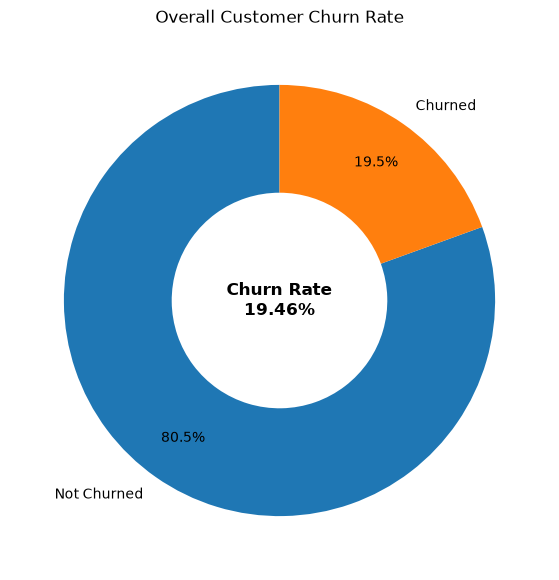

In [401]:


# Churn Rate
Churn_Rate = df['churned'].mean() * 100

print("Churn Rate =", round(Churn_Rate, 2), "%")

# Churned / Not Churned count
churn_count = df['churned'].value_counts().sort_index()

labels = ['Not Churned', 'Churned']

plt.figure(figsize=(7,7))

plt.pie(
    churn_count,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.5},
    pctdistance=0.78
)

# Center मध्ये overall churn rate
plt.text(
    0, 0,
    f"Churn Rate\n{Churn_Rate:.2f}%",
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    
)

plt.title("Overall Customer Churn Rate")
plt.savefig("overall customer churn rate.png")
plt.show()

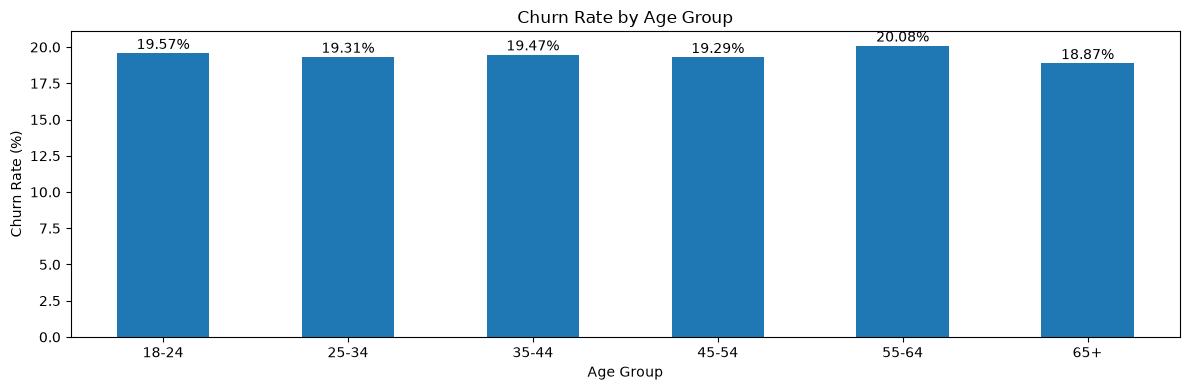

In [402]:

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False
)

# Churn rate by age group
churn_by_age = (
    df.groupby('age_group', observed=True)['churned']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)

# print(churn_by_age)

# Bar chart

ax = churn_by_age.plot(
    kind="bar",
    x="age_group",
    y="churn_rate",
    figsize=(12, 4),
    legend=False,
    grid=False,
    
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

# Values on bars
for i, v in enumerate(churn_by_age['churn_rate']):
    ax.text(
        i,
        v + 0.3,
        f"{v:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig("Churn Rate by Age Group.png")
plt.show()

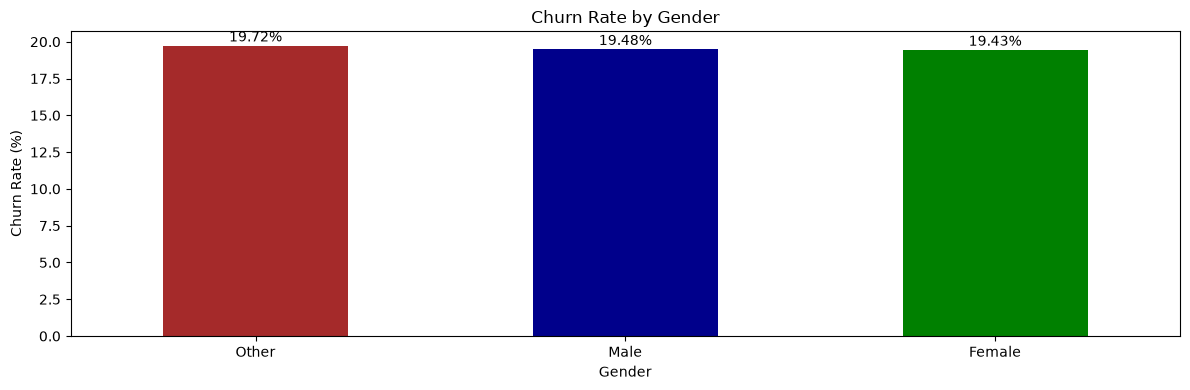

In [403]:
churn_by_gender=(
    df.groupby('gender')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="Churn rate %"))

# print(churn_by_gender)

# Bar chart

ax = churn_by_gender.plot(
        kind='bar',
        x="gender",
        y="Churn rate %",
        figsize=(12,4),
        legend=False,
        grid=False,
        color=['brown','darkblue','green']
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

# Values on bars
for i, v in enumerate(churn_by_gender["Churn rate %"]):
    ax.text(
        i,
        v + 0.3,
        f"{v:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig("Churn Rate by Gender.png")
plt.show()


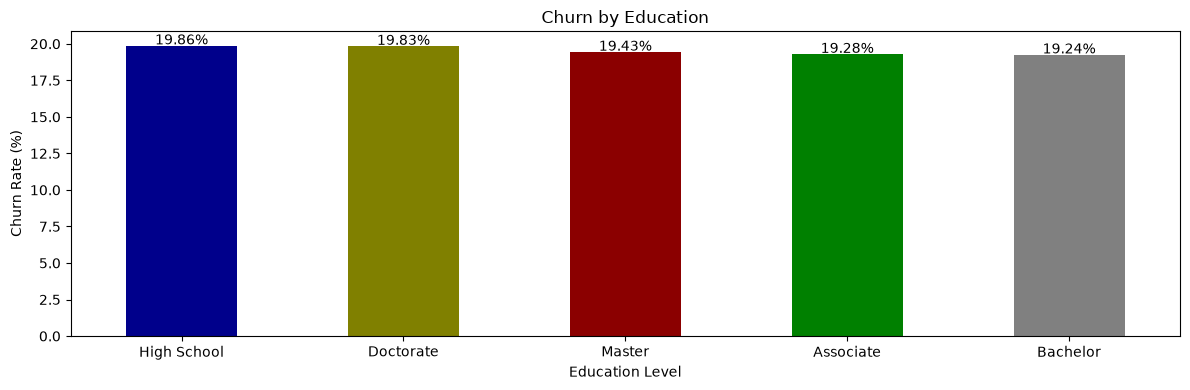

In [404]:
churn_by_education=(
    df.groupby('education_level')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="Churn rate %"))
# print(churn_by_education)

# Bar chart

ax = churn_by_education.plot(
    kind='bar',
    x="education_level",
    y="Churn rate %",
    figsize=(12,4),
    grid=False,
    legend=False,
    color=['darkblue','olive','darkred','green','grey']
)


plt.title("Churn by Education")
plt.xlabel("Education Level")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)


for i , v in enumerate(churn_by_education["Churn rate %"]):
    ax.text(
        i,
        v + 0.1,
        f"{v:.2f}%",
        ha="center"
    )


plt.tight_layout()
plt.savefig("Churn by Education.png")
plt.show()

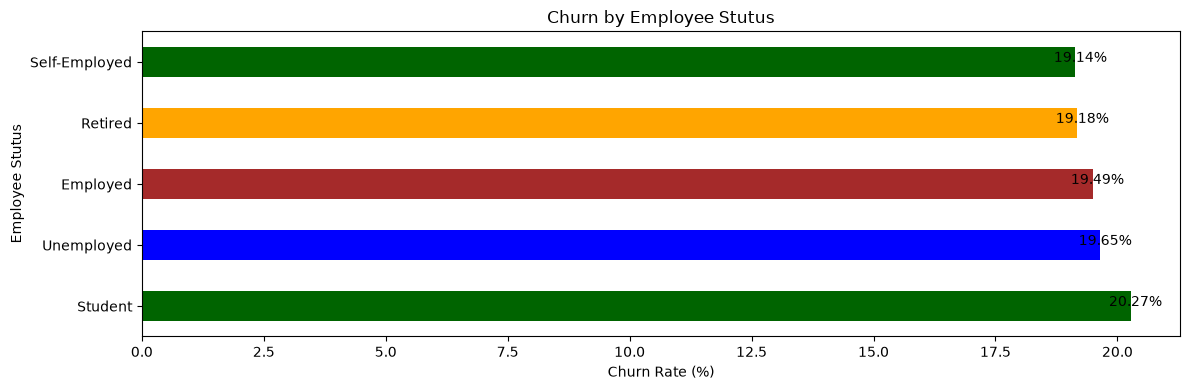

In [405]:
churn_by_emp=(
    df.groupby('employment_status')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="Churn rate %"))

# print(churn_by_emp)

# Bar Chart

ax = churn_by_emp.plot(
    kind='barh',
    x="employment_status",
    y="Churn rate %",
    figsize=(12,4),
    grid=False,
    legend=False,
    color=['darkgreen','blue','brown','orange']
)

plt.title("Churn by Employee Stutus")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Employee Stutus")
plt.xticks(rotation=0)


for i , v in enumerate(churn_by_emp["Churn rate %"]):
    ax.text(
            v + 0.1,
            i,
            f"{v:.2f}%",
            ha="center"
        )

plt.tight_layout()
plt.savefig("Churn by Employee Stutus.png")
plt.show()

#### B . Spending & Transaction Analysis Visualization

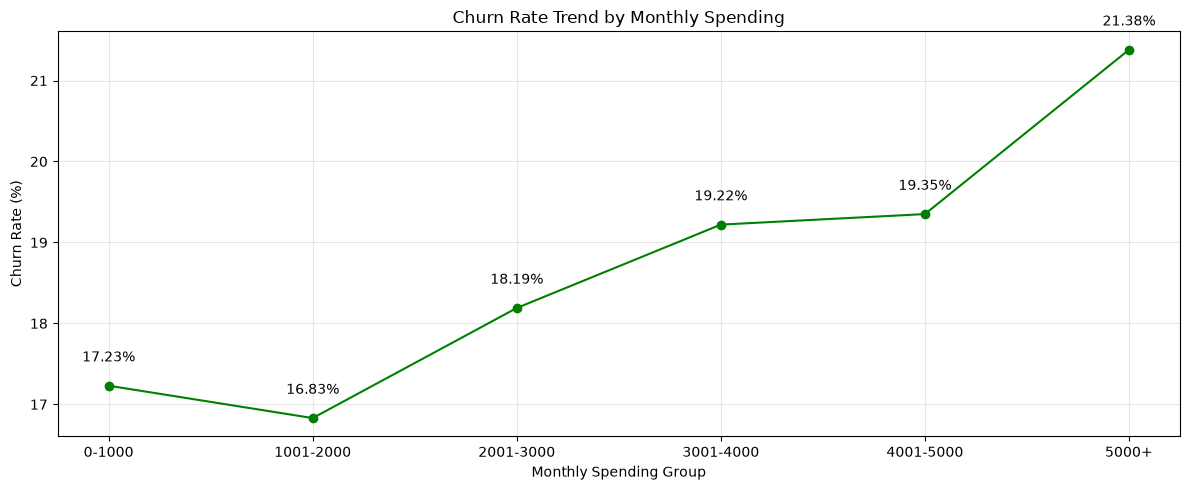

In [406]:
bins = [0, 1000, 2000, 3000, 4000, 5000, float('inf')]
labels = ['0-1000', '1001-2000', '2001-3000',
          '3001-4000', '4001-5000', '5000+']

df['spending_group'] = pd.cut(
    df['monthly_spending'],
    bins=bins,
    labels=labels
)
churn_by_spending = (
    df.groupby('spending_group')['churned']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)

# print(churn_by_spending)

ax = churn_by_spending.plot(
    kind='line',
    x='spending_group',
    y='churn_rate',
    marker='o',
    figsize=(12, 5),
    grid=True,
    legend=False,
    color='green'
)

# Point वर churn rate value
for i, v in enumerate(churn_by_spending['churn_rate']):
    ax.text(
        i,
        v + 0.3,
        f'{v:.2f}%',
        ha='center'
    )

plt.title('Churn Rate Trend by Monthly Spending')
plt.xlabel('Monthly Spending Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Churn Rate Trend by Monthly Spending.png")
plt.show()

  international_txn_group  churned rate %
0                     0-4           19.02
1                     5-9           19.80
2                   10-24           20.40
3                   25-49           20.84
4                   50-74           22.55
5                   75-99           22.05
6                    100+           30.77


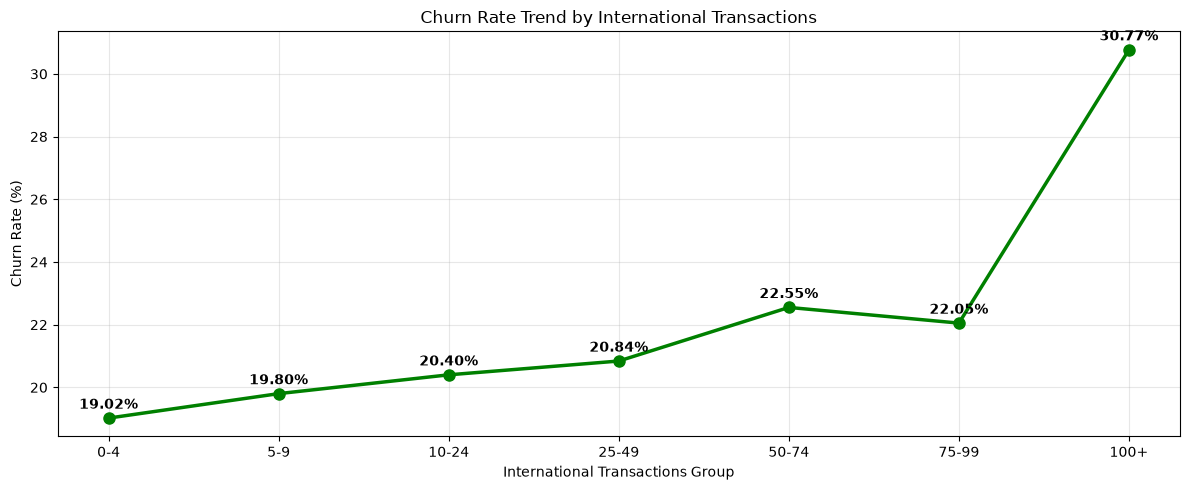

In [407]:

bins=[0,5,10,25,50,75,100,float("inf")]
labels=["0-4","5-9","10-24","25-49","50-74","75-99","100+"]

df["international_txn_group"]=pd.cut(df['international_transactions'],bins=bins,labels=labels, right=False)

international_transaction=(
    df.groupby('international_txn_group',observed=True)['churned']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="churned rate %")
    )

print(international_transaction)

ax = international_transaction.plot(
    kind='line',
    x='international_txn_group',
    y='churned rate %',
    marker='o',
    figsize=(12, 5),
    linewidth=2.5,
    markersize=8,
    grid=True,
    legend=False,
    color='green'
    
)

# Point वर churn rate value
for i, v in enumerate(international_transaction['churned rate %']):
    ax.text(
        i,
        v + 0.3,
        f'{v:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.title('Churn Rate Trend by International Transactions')
plt.xlabel('International Transactions Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("Churn Rate Trend by International Transactions.png")
plt.show()



#### C. Credit Card / Financial Behaviour Visualization

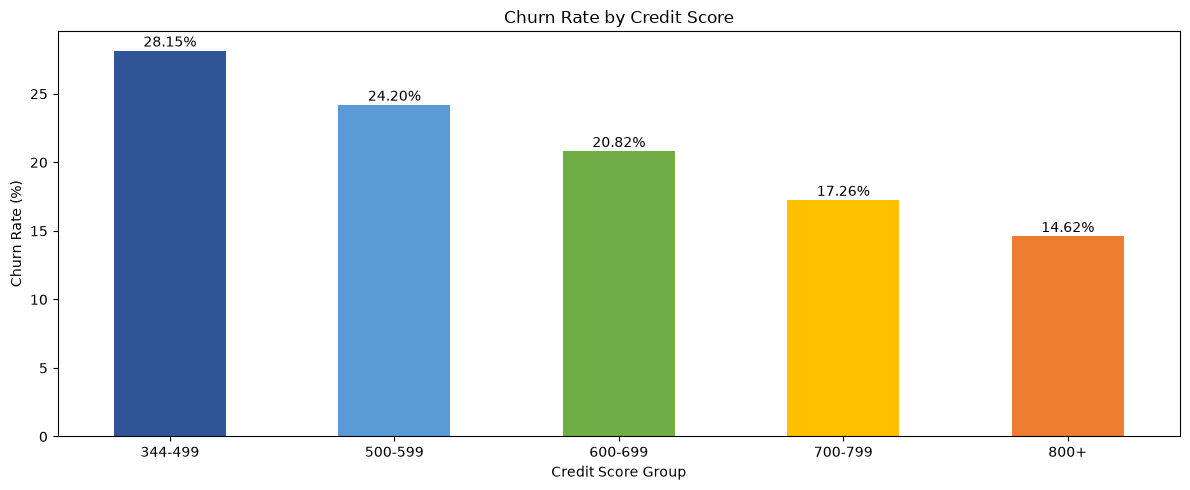

In [408]:
bins=[0,344,500,600,700,800,float('inf')]
labels=["0-343","344-499","500-599","600-699",'700-799',"800+"]

df['Credit_score_group']=pd.cut(df['credit_score'],bins=bins,labels=labels,right=False)


churn_by_credit=(
    df.groupby('Credit_score_group',observed=True)['churned']
        .mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
        .reset_index(name="churn rate")
    )

# print(churn_by_credit)

# Bar Plot
ax = churn_by_credit.plot(
    kind='bar',
    x='Credit_score_group',
    y='churn rate',
    figsize=(12, 5),
    grid=False,
    legend=False,
    color = [
    "#2F5597",  # Dark Blue
    "#5B9BD5",  # Blue
    "#70AD47",  # Green
    "#FFC000",  # Gold
    "#ED7D31",  # Orange
    "#A5A5A5",  # Gray
    "#4472C4"   # Medium Blue
]
)

# Add data labels
for i, v in enumerate(churn_by_credit['churn rate']):
    ax.text(
        i,
        v + 0.3,
        f'{v:.2f}%',
        ha='center'
    )

plt.title('Churn Rate by Credit Score')
plt.xlabel('Credit Score Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("Churn Rate by Credit Score.png")
plt.show()


  card_type  Churn rate %
0  Standard         19.64
1    Silver         19.43
2      Gold         19.25
3  Platinum         18.92


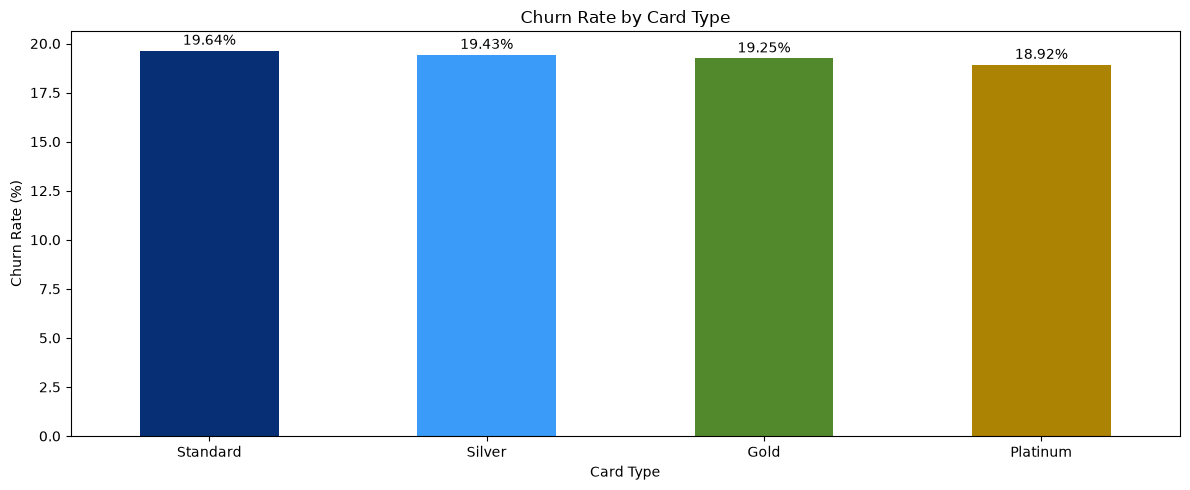

In [409]:
churn_by_card_type = (
    df.groupby('card_type')['churned']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .reset_index(name="Churn rate %")
)

print(churn_by_card_type)

ax = churn_by_card_type.plot(
    kind='bar',
    x='card_type',
    y='Churn rate %',
    figsize=(12, 5),
    grid=False,
    legend=False,
    color = [
    "#062F76",  # Dark Blue
    "#3A9CF8",  # Blue
    "#51892C",  # Green
    "#AD8304",  # Gold
]
)

# Add data labels
for i, v in enumerate(churn_by_card_type['Churn rate %']):
    ax.text(
        i,
        v + 0.3,
        f'{v:.2f}%',
        ha='center'
    )

plt.title('Churn Rate by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("Churn Rate by Card Type.png")
plt.show()



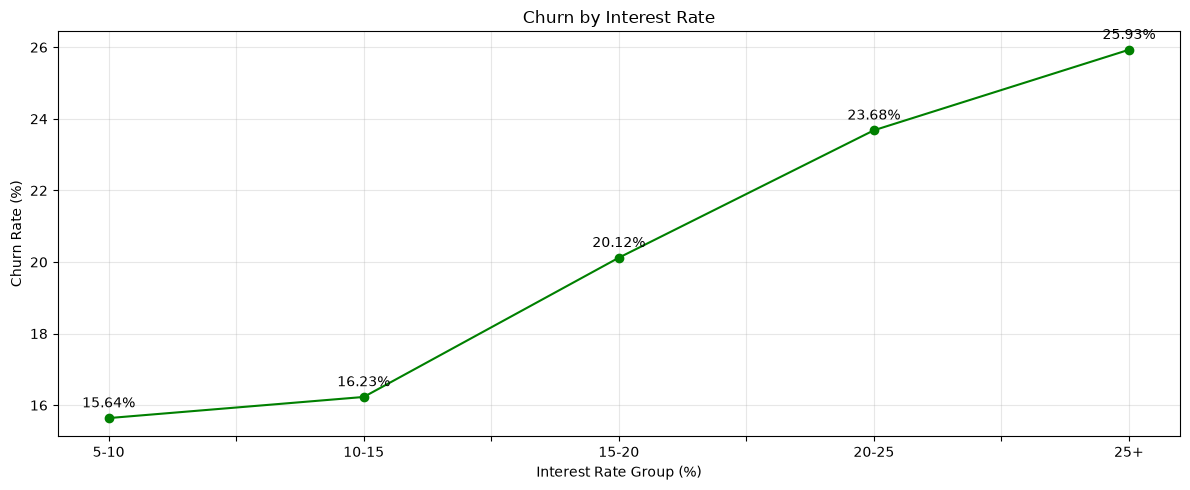

In [410]:
bins = [0, 5, 10, 15, 20, 25, float('inf')]
labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25+']

df['interest_rate_group'] = pd.cut(
    df['interest_rate'],
    bins=bins,
    labels=labels,
    right=False
)

churn_by_interest_rate=(
    df.groupby('interest_rate_group')['churned']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=True)
    .reset_index(name="churn rate %")
    )
# print(churn_by_interest_rate)

# Line Chart

ax = churn_by_interest_rate.plot(
    kind='line',
    x='interest_rate_group',
    y='churn rate %',
    marker='o',
    figsize=(12, 5),
    grid=True,
    legend=False,
    color='green',
)

for i, v in enumerate(churn_by_interest_rate['churn rate %']):
    ax.text(
        i,
        v + 0.3,
        f'{v:.2f}%',
        ha='center'
        
    )

plt.title('Churn by Interest Rate')
plt.xlabel('Interest Rate Group (%)')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig("Churn by Interest Rate.png")
plt.show()

# Project Complete 